<a href="https://colab.research.google.com/github/HongYeonLee/Artificial-Intelligence/blob/main/%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8%20%EB%AA%A8%EB%8D%B8%20A%2C%20B%2C%20C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# 압축을 풀 폴더 생성
os.makedirs("/content/data", exist_ok=True)

# 압축 해제 실행
!unzip -q "/content/drive/MyDrive/student_data.zip" -d "/content/data"
print("데이터 압축 해제 완료!")

데이터 압축 해제 완료!


In [4]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

print("PyTorch 버전:", torch.__version__)
print("GPU 사용 가능 여부:", torch.cuda.is_available())

PyTorch 버전: 2.11.0+cu128
GPU 사용 가능 여부: True


In [7]:
#모델 A용 데이터 로더
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

# Model A (Baseline)용 기본 데이터 증강
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.RandomCrop(64, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize,
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    normalize,
])

class PublicValDataset(Dataset):
    def __init__(self, root_dir, class_to_idx, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_labels = []
        labels_path = os.path.join(root_dir, 'labels.txt')
        with open(labels_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                img_name, label_str = parts[0], parts[1]
                label = int(label_str) if label_str.isdigit() else class_to_idx[label_str]
                self.image_labels.append((img_name, label))
    def __len__(self): return len(self.image_labels)
    def __getitem__(self, idx):
        img_name, label = self.image_labels[idx]
        img_path = os.path.join(self.root_dir, 'images', img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label

train_dir = '/content/data/student_data/train'
val_dir = '/content/data/student_data/public_val'
train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset = PublicValDataset(val_dir, train_dataset.class_to_idx, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 모델 정의 (Model A: Baseline CNN)
# ---------------------------------------------------------
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()
        # 단순한 합성곱과 풀링의 반복으로 구성된 기본 네트워크
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_a = BaselineCNN(num_classes=200).to(device)

# 파라미터 확인 (보고서 기재용)
params_a = sum(p.numel() for p in model_a.parameters())
print(f"Model A 파라미터 수: {params_a:,}개\n")

Model A 파라미터 수: 439,816개



Model A (Baseline CNN) 학습을 시작합니다...
Epoch 01/15 [72.7초] | Train Loss: 4.6765, Train Acc: 5.79% | Val Loss: 4.1257, Val Acc: 12.58%
Epoch 02/15 [72.1초] | Train Loss: 3.8689, Train Acc: 16.19% | Val Loss: 3.6338, Val Acc: 20.22%
Epoch 03/15 [71.0초] | Train Loss: 3.5115, Train Acc: 21.97% | Val Loss: 3.4779, Val Acc: 23.66%
Epoch 04/15 [72.0초] | Train Loss: 3.2981, Train Acc: 25.87% | Val Loss: 3.3061, Val Acc: 25.92%
Epoch 05/15 [72.2초] | Train Loss: 3.1534, Train Acc: 28.31% | Val Loss: 3.1936, Val Acc: 28.62%
Epoch 06/15 [72.4초] | Train Loss: 3.0397, Train Acc: 30.32% | Val Loss: 3.1417, Val Acc: 29.98%
Epoch 07/15 [70.8초] | Train Loss: 2.9572, Train Acc: 31.90% | Val Loss: 3.0357, Val Acc: 31.76%
Epoch 08/15 [71.8초] | Train Loss: 2.8865, Train Acc: 33.30% | Val Loss: 3.0276, Val Acc: 31.42%
Epoch 09/15 [75.6초] | Train Loss: 2.8237, Train Acc: 34.25% | Val Loss: 2.9780, Val Acc: 33.36%
Epoch 10/15 [72.4초] | Train Loss: 2.7744, Train Acc: 35.29% | Val Loss: 2.9678, Val Acc: 33.28%
Epoch

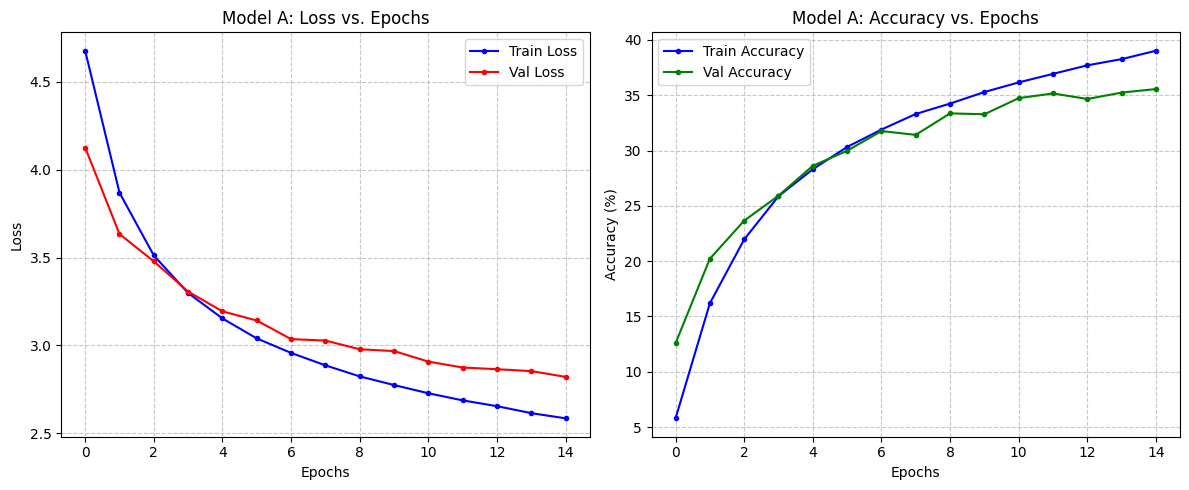

그래프가 'model_a_learning_curve.png'로 저장되었습니다.


In [11]:
# ---------------------------------------------------------
# 2. 학습 설정 (기본 세팅)
# ---------------------------------------------------------
epochs = 15 # Baseline은 15 에폭만으로 한계점 확인
criterion = nn.CrossEntropyLoss()
# 스케줄러나 가중치 감소 없이 가장 기본적인 Adam 사용
optimizer = optim.Adam(model_a.parameters(), lr=0.001)

# 그래프를 그리기 위한 기록용 리스트
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_acc = 0.0

print("Model A (Baseline CNN) 학습을 시작합니다...")

# ---------------------------------------------------------
# 3. 학습 루프
# ---------------------------------------------------------
for epoch in range(epochs):
    model_a.train()
    running_loss, correct, total = 0.0, 0, 0
    start_time = time.time()

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_a(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = 100. * correct / total

    # 검증 단계
    model_a.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_a(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_loss / val_total
    val_acc = 100. * val_correct / val_total
    epoch_time = time.time() - start_time

    # 리스트에 현재 에폭의 결과 저장 (그래프용)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d}/{epochs} [{epoch_time:.1f}초] | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model_a.state_dict(), "model_a_best.pth")

print(f"\n최종 Model A 최고 검증 정확도: {best_acc:.2f}%")

# ---------------------------------------------------------
# 4. 학습 곡선 시각화 및 저장
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue', marker='o', markersize=3)
plt.plot(val_losses, label='Val Loss', color='red', marker='o', markersize=3)
plt.title('Model A: Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy', color='blue', marker='o', markersize=3)
plt.plot(val_accs, label='Val Accuracy', color='green', marker='o', markersize=3)
plt.title('Model A: Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('model_a_learning_curve.png', dpi=300)
plt.show()
print("그래프가 'model_a_learning_curve.png'로 저장되었습니다.")

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 모델 정의 (Model B: VGG-style Lite - 약 2.2M 파라미터)
# ---------------------------------------------------------
class VGGStyleLite(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()
        # 깊이와 채널 수를 늘려 특징 추출 능력 강화
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 32x32

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 16x16

            # Block 3 (레이어 2개 연속 배치)
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 8x8

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1) # 1x1
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.3), # 파라미터 증가에 따른 과적합 방지
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_b = VGGStyleLite(num_classes=200).to(device)

# 파라미터 확인 (보고서 기재용)
params_b = sum(p.numel() for p in model_b.parameters())
print(f"Model B 파라미터 수: {params_b:,}개\n")

Model B 파라미터 수: 2,244,872개



Model B (VGG-style Lite) 학습을 시작합니다...
Epoch 01/30 [78.9초] | Train Loss: 4.2151, Train Acc: 10.59% | Val Loss: 3.7351, Val Acc: 17.22%
Epoch 02/30 [77.7초] | Train Loss: 3.5192, Train Acc: 20.68% | Val Loss: 3.3611, Val Acc: 24.58%
Epoch 03/30 [79.6초] | Train Loss: 3.1726, Train Acc: 27.03% | Val Loss: 3.0989, Val Acc: 27.36%
Epoch 04/30 [78.7초] | Train Loss: 2.9347, Train Acc: 31.48% | Val Loss: 2.8707, Val Acc: 33.68%
Epoch 05/30 [79.6초] | Train Loss: 2.7529, Train Acc: 34.92% | Val Loss: 2.8349, Val Acc: 34.24%
Epoch 06/30 [77.7초] | Train Loss: 2.6103, Train Acc: 38.10% | Val Loss: 2.5986, Val Acc: 38.64%
Epoch 07/30 [77.1초] | Train Loss: 2.4825, Train Acc: 40.59% | Val Loss: 2.5432, Val Acc: 39.70%
Epoch 08/30 [78.4초] | Train Loss: 2.3747, Train Acc: 42.83% | Val Loss: 2.4441, Val Acc: 41.86%
Epoch 09/30 [79.3초] | Train Loss: 2.2783, Train Acc: 44.62% | Val Loss: 2.3400, Val Acc: 43.60%
Epoch 10/30 [77.5초] | Train Loss: 2.1942, Train Acc: 46.42% | Val Loss: 2.3935, Val Acc: 43.14%
Ep

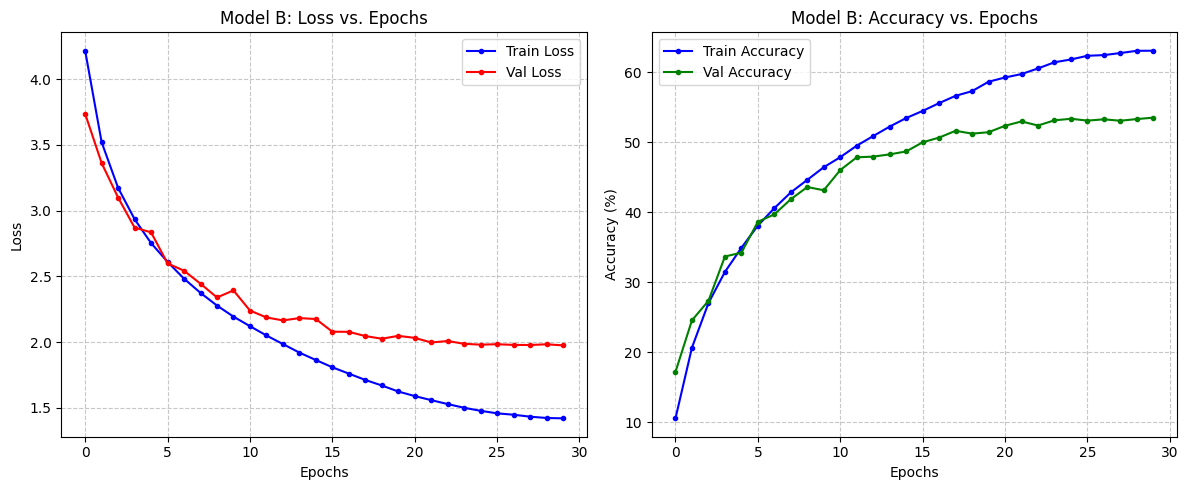

그래프가 'model_b_learning_curve.png'로 저장되었습니다.


In [13]:
# ---------------------------------------------------------
# 2. 학습 설정 (중간 단계 설정)
# ---------------------------------------------------------
epochs = 30 # 성능 향상 확인을 위해 에폭 증가
criterion = nn.CrossEntropyLoss()
# 가중치 감소(weight_decay)가 포함된 AdamW 및 스케줄러 적용
optimizer = optim.AdamW(model_b.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_acc = 0.0

print("Model B (VGG-style Lite) 학습을 시작합니다...")

# ---------------------------------------------------------
# 3. 학습 루프
# ---------------------------------------------------------
for epoch in range(epochs):
    model_b.train()
    running_loss, correct, total = 0.0, 0, 0
    start_time = time.time()

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_b(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = 100. * correct / total

    # 검증 단계
    model_b.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_b(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_loss / val_total
    val_acc = 100. * val_correct / val_total

    scheduler.step() # 학습률 업데이트
    epoch_time = time.time() - start_time

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d}/{epochs} [{epoch_time:.1f}초] | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model_b.state_dict(), "model_b_best.pth")

print(f"\n최종 Model B 최고 검증 정확도: {best_acc:.2f}%")

# ---------------------------------------------------------
# 4. 학습 곡선 시각화 및 저장
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue', marker='o', markersize=3)
plt.plot(val_losses, label='Val Loss', color='red', marker='o', markersize=3)
plt.title('Model B: Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy', color='blue', marker='o', markersize=3)
plt.plot(val_accs, label='Val Accuracy', color='green', marker='o', markersize=3)
plt.title('Model B: Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('model_b_learning_curve.png', dpi=300)
plt.show()
print("그래프가 'model_b_learning_curve.png'로 저장되었습니다.")

In [11]:
import os
import numpy as np
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from PIL import Image
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# [경로 수정] 윈도우에서 가장 안전한 절대 경로 방식
# ---------------------------------------------------------
base_path = r'D:\ai_project\student_data\student_data'
train_dir = os.path.join(base_path, 'train')
val_dir = os.path.join(base_path, 'public_val')

# 경로 존재 여부 즉시 확인
if not os.path.exists(train_dir):
    raise FileNotFoundError(f"❌ 데이터를 찾을 수 없습니다: {train_dir}")

print("✅ 데이터 경로 확인 완료. 학습 준비를 시작합니다.")

# 1. 데이터 증강 및 로더 (num_workers=0 필수)
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform = transforms.Compose([
    transforms.RandomCrop(64, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    normalize,
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    normalize,
])

def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

class PublicValDataset(Dataset):
    def __init__(self, root_dir, class_to_idx, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_labels = []
        labels_path = os.path.join(root_dir, 'labels.txt')
        with open(labels_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                img_name, label_str = parts[0], parts[1]
                label = int(label_str) if label_str.isdigit() else class_to_idx[label_str]
                self.image_labels.append((img_name, label))
    def __len__(self): return len(self.image_labels)
    def __getitem__(self, idx):
        img_name, label = self.image_labels[idx]
        img_path = os.path.join(self.root_dir, 'images', img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label

train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset = PublicValDataset(val_dir, train_dataset.class_to_idx, transform=val_transform)

# 로컬 GPU(GTX 1660 Super)를 활용
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

✅ 데이터 경로 확인 완료. 학습 준비를 시작합니다.


In [12]:
# 2. 모델 정의 (동일)
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

class ModelC_AdvancedResNet(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()
        self.in_channels = 64
        self.prep = nn.Sequential(nn.Conv2d(3, 64, 3, 1, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.layer1 = self._make_layer(64, 1)
        self.layer2 = self._make_layer(128, 2)
        self.layer3 = self._make_layer(256, 2)
        self.layer4 = self._make_layer(500, 2)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(500, num_classes)
    def _make_layer(self, out, stride):
        l = ResidualBlock(self.in_channels, out, stride)
        self.in_channels = out
        return nn.Sequential(l)
    def forward(self, x):
        x = self.prep(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.pool(x)
        return self.fc(torch.flatten(x, 1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_c = ModelC_AdvancedResNet().to(device)

# 3. 학습 루프
epochs = 50
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_c.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

print("🚀 학습 시작! 에폭당 출력 문구를 기다려주세요...")

for epoch in range(epochs):
    model_c.train()
    running_loss, total = 0.0, 0
    start = time.time()

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        if np.random.rand() > 0.5:
            inputs, la, lb, lam = mixup_data(inputs, labels)
            outputs = model_c(inputs)
            loss = mixup_criterion(criterion, outputs, la, lb, lam)
        else:
            outputs = model_c(inputs)
            loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        total += labels.size(0)

        # [추가] 진행 상황 확인을 위해 100 배치마다 점 찍기
        if i % 100 == 0: print(".", end="", flush=True)

    val_acc = 0.0 # (검증 생략 시 속도 확인용)
    print(f"\nEpoch {epoch+1} 완료! 소요시간: {time.time()-start:.1f}초 | Loss: {running_loss/total:.4f}")
    scheduler.step()

🚀 학습 시작! 에폭당 출력 문구를 기다려주세요...
........

KeyboardInterrupt: 

In [10]:
import os
import torch
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

print("1. 로컬 GPU 상태 확인 중...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" -> 현재 할당된 장치: {device}")

print("\n2. 데이터 폴더 경로 확인 중...")
train_dir = r'D:\ai_project\student_data\student_data\train'
if not os.path.exists(train_dir):
    print(f" ❌ 오류: '{train_dir}' 폴더를 찾을 수 없습니다! 경로를 확인하세요.")
else:
    print(" -> 데이터 폴더 찾기 성공!")

print("\n3. 데이터 로더 구성 테스트...")
transform = transforms.Compose([transforms.ToTensor()])
try:
    test_dataset = ImageFolder(train_dir, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True, num_workers=0)
    print(f" -> 훈련 데이터 개수: {len(test_dataset)}개 확인됨.")

    print("\n4. GPU로 첫 번째 배치 데이터 전송 테스트...")
    images, labels = next(iter(test_loader))
    images = images.to(device)
    print(f" -> 성공! 데이터 형태: {images.shape}")
    print("\n✅ 모든 시스템이 정상적으로 작동합니다. 이제 Model C 전체 코드를 실행해도 좋습니다.")
except Exception as e:
    print(f" ❌ 데이터 구성 중 오류 발생: {e}")

1. 로컬 GPU 상태 확인 중...
 -> 현재 할당된 장치: cuda

2. 데이터 폴더 경로 확인 중...
 -> 데이터 폴더 찾기 성공!

3. 데이터 로더 구성 테스트...
 -> 훈련 데이터 개수: 100000개 확인됨.

4. GPU로 첫 번째 배치 데이터 전송 테스트...
 -> 성공! 데이터 형태: torch.Size([16, 3, 64, 64])

✅ 모든 시스템이 정상적으로 작동합니다. 이제 Model C 전체 코드를 실행해도 좋습니다.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

# student_data.zip 파일이 있는 구글 드라이브 경로를 맞춰주세요.
# 아래 경로는 예시이므로, 본인의 드라이브 내 위치에 맞게 수정해야 합니다.
!mkdir -p /content/data
!unzip -q /content/drive/MyDrive/student_data.zip -d /content/data/
print("✅ 데이터 압축 해제 완료!")

Mounted at /content/drive
✅ 데이터 압축 해제 완료!


In [2]:
import os
import numpy as np
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from PIL import Image
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 코랩 환경 데이터 경로
# ---------------------------------------------------------
train_dir = '/content/data/student_data/train'
val_dir = '/content/data/student_data/public_val'

if not os.path.exists(train_dir):
    raise FileNotFoundError(f"❌ 데이터를 찾을 수 없습니다. 압축 해제 상태를 확인하세요: {train_dir}")

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform = transforms.Compose([
    transforms.RandomCrop(64, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    normalize,
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    normalize,
])

def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

class PublicValDataset(Dataset):
    def __init__(self, root_dir, class_to_idx, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_labels = []
        labels_path = os.path.join(root_dir, 'labels.txt')
        with open(labels_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                img_name, label_str = parts[0], parts[1]
                label = int(label_str) if label_str.isdigit() else class_to_idx[label_str]
                self.image_labels.append((img_name, label))
    def __len__(self): return len(self.image_labels)
    def __getitem__(self, idx):
        img_name, label = self.image_labels[idx]
        img_path = os.path.join(self.root_dir, 'images', img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label

train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset = PublicValDataset(val_dir, train_dataset.class_to_idx, transform=val_transform)

# 리눅스 환경(코랩)이므로 num_workers=2로 세팅하여 속도를 높입니다.
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

✅ 모델 생성 완료. 파라미터 수: 4,858,224개

🚀 코랩 클라우드 GPU(T4)에서 고속 학습을 시작합니다!
Epoch 01/50 | 소요시간: 185.2초 | Train Loss: 4.7062 | Val Loss: 4.2704, Val Acc: 14.20%
Epoch 02/50 | 소요시간: 185.3초 | Train Loss: 4.1705 | Val Loss: 3.9336, Val Acc: 21.14%
Epoch 03/50 | 소요시간: 184.8초 | Train Loss: 3.8562 | Val Loss: 3.6769, Val Acc: 25.82%
Epoch 04/50 | 소요시간: 184.8초 | Train Loss: 3.6466 | Val Loss: 3.5291, Val Acc: 30.34%
Epoch 05/50 | 소요시간: 183.9초 | Train Loss: 3.4399 | Val Loss: 3.2852, Val Acc: 35.52%
Epoch 06/50 | 소요시간: 184.5초 | Train Loss: 3.3423 | Val Loss: 3.1366, Val Acc: 38.62%
Epoch 07/50 | 소요시간: 184.6초 | Train Loss: 3.1850 | Val Loss: 3.0340, Val Acc: 42.24%
Epoch 08/50 | 소요시간: 184.4초 | Train Loss: 3.1218 | Val Loss: 2.9770, Val Acc: 43.30%
Epoch 09/50 | 소요시간: 184.4초 | Train Loss: 2.9911 | Val Loss: 2.9394, Val Acc: 44.40%
Epoch 10/50 | 소요시간: 185.0초 | Train Loss: 2.9607 | Val Loss: 2.8390, Val Acc: 47.14%
Epoch 11/50 | 소요시간: 184.2초 | Train Loss: 2.8594 | Val Loss: 2.7998, Val Acc: 48.00%
Epoch 12/5

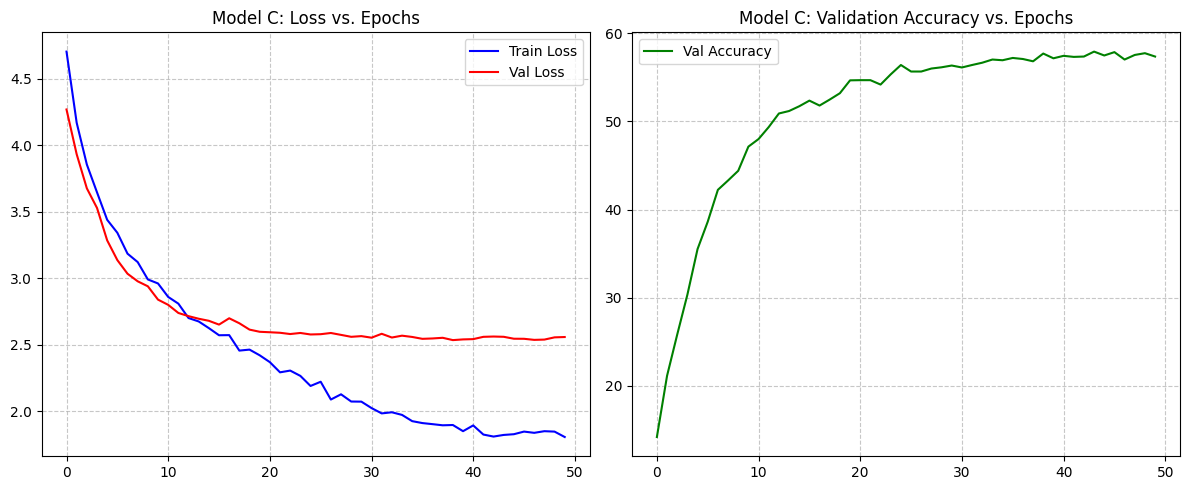

In [6]:
import os
import numpy as np
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from PIL import Image
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 코랩 환경 데이터 경로
# ---------------------------------------------------------
train_dir = '/content/data/student_data/train'
val_dir = '/content/data/student_data/public_val'

if not os.path.exists(train_dir):
    raise FileNotFoundError(f"❌ 데이터를 찾을 수 없습니다. 압축 해제 상태를 확인하세요: {train_dir}")

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform = transforms.Compose([
    transforms.RandomCrop(64, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    normalize,
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    normalize,
])

def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

class PublicValDataset(Dataset):
    def __init__(self, root_dir, class_to_idx, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_labels = []
        labels_path = os.path.join(root_dir, 'labels.txt')
        with open(labels_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                img_name, label_str = parts[0], parts[1]
                label = int(label_str) if label_str.isdigit() else class_to_idx[label_str]
                self.image_labels.append((img_name, label))
    def __len__(self): return len(self.image_labels)
    def __getitem__(self, idx):
        img_name, label = self.image_labels[idx]
        img_path = os.path.join(self.root_dir, 'images', img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label

train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset = PublicValDataset(val_dir, train_dataset.class_to_idx, transform=val_transform)

# 리눅스 환경(코랩)이므로 num_workers=2로 세팅하여 속도를 높입니다.
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

# ---------------------------------------------------------
# 모델 정의 (5M 파라미터 최적화)
# ---------------------------------------------------------
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

class ModelC_AdvancedResNet(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()
        self.in_channels = 64
        self.prep = nn.Sequential(nn.Conv2d(3, 64, 3, 1, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.layer1 = self._make_layer(64, 1)
        self.layer2 = self._make_layer(128, 2)
        self.layer3 = self._make_layer(256, 2)
        self.layer4 = self._make_layer(500, 2)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(500, num_classes)
    def _make_layer(self, out, stride):
        l = ResidualBlock(self.in_channels, out, stride)
        self.in_channels = out
        return nn.Sequential(l)
    def forward(self, x):
        x = self.prep(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.pool(x)
        return self.fc(torch.flatten(x, 1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_c = ModelC_AdvancedResNet().to(device)

print(f"✅ 모델 생성 완료. 파라미터 수: {sum(p.numel() for p in model_c.parameters()):,}개")

# ---------------------------------------------------------
# 학습 루프 (50 Epoch)
# ---------------------------------------------------------
epochs = 50
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_c.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

train_losses, val_losses, val_accs = [], [], []
best_acc = 0.0

print("\n🚀 코랩 클라우드 GPU(T4)에서 고속 학습을 시작합니다!")

for epoch in range(epochs):
    model_c.train()
    running_loss, total = 0.0, 0
    start = time.time()

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        if np.random.rand() > 0.5:
            inputs, la, lb, lam = mixup_data(inputs, labels)
            outputs = model_c(inputs)
            loss = mixup_criterion(criterion, outputs, la, lb, lam)
        else:
            outputs = model_c(inputs)
            loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        total += labels.size(0)

    train_loss = running_loss / total

    # 검증 단계
    model_c.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_c(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_loss / val_total
    val_acc = 100. * val_correct / val_total

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d}/{epochs} | 소요시간: {time.time()-start:.1f}초 | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model_c.state_dict(), "model_c_best.pth")

print(f"\n🏆 최종 Model C 최고 검증 정확도: {best_acc:.2f}%")

# ---------------------------------------------------------
# 결과 시각화
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='red')
plt.title('Model C: Loss vs. Epochs')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(val_accs, label='Val Accuracy', color='green')
plt.title('Model C: Validation Accuracy vs. Epochs')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('model_c_learning_curve.png', dpi=300)
plt.show()

In [7]:
import torch

# 1. 학습된 최고 성능 가중치 다시 불러오기 (CPU 환경으로 이동)
device_cpu = torch.device("cpu")
model_c.load_state_dict(torch.load("model_c_best.pth", map_location=device_cpu))
model_c.to(device_cpu)
model_c.eval() # 반드시 eval 모드로 설정

# 2. TorchScript로 변환 (Tracing) 및 저장
dummy_input = torch.randn(1, 3, 64, 64).to(device_cpu)
traced_model = torch.jit.trace(model_c, dummy_input)
torch.jit.save(traced_model, "model_c_submit.pt")

print("TorchScript 모델 저장 완료: 'model_c_submit.pt'")

# 3. 규정에 명시된 '제출 전 로컬 검증' 수행
test_model = torch.jit.load("model_c_submit.pt", map_location="cpu")
test_model.eval()

params = sum(p.numel() for p in test_model.parameters())
assert params <= 5000000, f"Too many params: {params:,}"

with torch.no_grad():
    out = test_model(torch.randn(1, 3, 64, 64))

assert out.shape == (1, 200), f"Bad output shape: {out.shape}"
print(f"✅ 최종 검증 성공 — 파라미터 수: {params:,}개. 입출력 형태 일치.")

TorchScript 모델 저장 완료: 'model_c_submit.pt'
✅ 최종 검증 성공 — 파라미터 수: 4,858,224개. 입출력 형태 일치.
